# Predicting F1 Pit Stops

## Importing initial libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

## Step 1: Data loading

In [2]:
train_data = pd.read_csv("train.csv")
test_data = pd.read_csv("test.csv")

In [3]:
train_data = train_data.drop("id", axis=1)

## Step 2: Initial data understanding

In [4]:
train_data.shape

(439140, 15)

**439,140 rows × 15 columns.** Large dataset — enough data to train complex models without overfitting being a major concern. 15 columns is manageable.

In [5]:
train_data.head()

,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


The data is **shuffled** — rows come from different years and races mixed together. This is good; a train/test split won't accidentally isolate an entire season in the test set. Row 3 (`Pre-Season Testing`, 2023) stands out immediately — this is not a real race and pit stop behaviour here is fundamentally different from competitive racing. Worth flagging for feature engineering.

In [6]:
train_data.tail()

,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
439135,D755,MEDIUM,Miami Grand Prix,2023,0,49,2,8.0,17,92.638,-0.076,-15.859,0.859649,0.0,0.0
439136,D731,MEDIUM,Miami Grand Prix,2023,0,49,2,5.0,1,85.890,-0.083,-4.907,0.859649,0.0,0.0
439137,D716,MEDIUM,Miami Grand Prix,2023,0,49,2,18.0,1,91.644,-0.182,-56.371,0.942308,0.0,0.0
439138,D665,HARD,Abu Dhabi Grand Prix,2023,0,48,3,10.0,1,89.947,-0.001,-20.721,0.827586,1.0,0.0
439139,D714,HARD,Miami Grand Prix,2023,0,49,2,32.0,1,91.691,-0.123,-15.828,0.859649,0.0,0.0


Tail looks consistent with the head — no anomalies at the end of the file. Data appears uniformly structured throughout.

In [7]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 439140 entries, 0 to 439139
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Driver                  439140 non-null  object 
 1   Compound                439140 non-null  object 
 2   Race                    439140 non-null  object 
 3   Year                    439140 non-null  int64  
 4   PitStop                 439140 non-null  int64  
 5   LapNumber               439140 non-null  int64  
 6   Stint                   439140 non-null  int64  
 7   TyreLife                439140 non-null  float64
 8   Position                439140 non-null  int64  
 9   LapTime (s)             439140 non-null  float64
 10  LapTime_Delta           439140 non-null  float64
 11  Cumulative_Degradation  439140 non-null  float64
 12  RaceProgress            439140 non-null  float64
 13  Position_Change         439140 non-null  float64
 14  PitNextLap          

**Three things stand out:**

- **No nulls** — all 439,140 entries are non-null across all 15 columns. Clean dataset.
- `TyreLife`, `Position_Change`, and `PitNextLap` are stored as `float64` but are whole numbers — need casting to `int64`.
- Three `object` columns: `Driver`, `Compound`, `Race` — all categorical, will need encoding.

In [8]:
train_data.describe(include = "all")

,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
count,439140,439140,439140,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000
unique,887,5,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,MAS,MEDIUM,Dutch Grand Prix,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1682,211141,24462,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,2023.523544,0.136118,23.105909,1.789113,14.158231,9.630339,90.948735,-3.770040,-25.721759,0.337661,0.101542,0.198982
std,NaN,NaN,NaN,1.024930,0.342915,16.958261,0.950194,9.801338,5.278770,19.772769,43.945759,54.766573,0.253277,4.006765,0.399235
min,NaN,NaN,NaN,2022.000000,0.000000,1.000000,1.000000,1.000000,1.000000,67.694000,-2403.895000,-274.564000,0.012821,-18.000000,0.000000
25%,NaN,NaN,NaN,2023.000000,0.000000,9.000000,1.000000,6.000000,5.000000,82.621000,-8.884000,-46.566250,0.129870,-1.000000,0.000000
50%,NaN,NaN,NaN,2024.000000,0.000000,19.000000,2.000000,12.000000,10.000000,90.521000,-0.295000,-20.994000,0.269231,0.000000,0.000000
75%,NaN,NaN,NaN,2024.000000,0.000000,36.000000,2.000000,20.000000,14.000000,98.471000,0.115000,-6.199000,0.513158,2.000000,0.000000


* `Driver` - 887 unique drivers, top is MAS with 1,682 appearances. Very high cardinality. Target encoding will collapse it to one column.

* `Compound` - only 5 unique values (HARD, MEDIUM, SOFT, INTERMEDIATE, WET), with MEDIUM being dominant at 211,141 rows (48% of the data). Low cardinality, one-hot encoding is clean here.

* `Race` - 26 unique races, Dutch Grand Prix is the most frequent at 24,462 rows. High cardinality like Driver — target encoding applies.

* `PitNextLap` - mean of 0.199, meaning roughly 20% of rows are positive (will pit next lap). This is a class imbalance - 80% class 0, 20% class 1. Use `class_weight='balanced'` in the model, and evaluate using F1-score or AUC-ROC rather than plain accuracy.

> This is a binary classification problem on tabular, structured data with a mix of numerical and categorical features, no missing values, some outliers to clean, a mild class imbalance (80/20), and a large enough dataset (439K rows) to support complex models. The presence of time-ordered features like LapNumber, TyreLife, RaceProgress, and Stint gives it a sequential character.

## Step 3: Separate numerical & categorical columns

In [9]:
feature_cols = [col for col in train_data.columns if col != "PitNextLap"]

num_cols = train_data[feature_cols].select_dtypes(include=np.number).columns.tolist()
cat_cols = train_data[feature_cols].select_dtypes(exclude=np.number).columns.tolist()

print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)

Numerical columns: ['Year', 'PitStop', 'LapNumber', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress', 'Position_Change']
Categorical columns: ['Driver', 'Compound', 'Race']


**Numerical (11):** `Year`, `PitStop`, `LapNumber`, `Stint`, `TyreLife`, `Position`, `LapTime (s)`, `LapTime_Delta`, `Cumulative_Degradation`, `RaceProgress`, `Position_Change`

**Categorical (3):** `Driver`, `Compound`, `Race`

**Mental sub-categories to keep in mind:**
- **Binary flag:** `PitStop` (0/1) — skip histplots, skewness, and scaling on this one
- **Ordinal/bounded:** `LapNumber`, `Stint`, `TyreLife`, `Position` — natural order, hard ceiling/floor
- **Continuous:** `LapTime (s)`, `LapTime_Delta`, `Cumulative_Degradation`, `RaceProgress`, `Position_Change` — outlier treatment applies here
- **High cardinality:** `Driver` (887), `Race` (26) — target encoding candidates
- **Low cardinality:** `Compound` (5) — straightforward one-hot encoding

## Step 4: Basic cleaning

In [10]:
print("Duplicate rows:", train_data.duplicated().sum())
train_data.drop_duplicates(inplace=True)
print("Shape after dropping duplicates:", train_data.shape)

Duplicate rows: 0
Shape after dropping duplicates: (439140, 15)


**Zero duplicates** in 439K rows — expected for this type of data since each row represents a unique driver on a specific lap in a specific race. No rows removed.

In [11]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 439140 entries, 0 to 439139
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Driver                  439140 non-null  object 
 1   Compound                439140 non-null  object 
 2   Race                    439140 non-null  object 
 3   Year                    439140 non-null  int64  
 4   PitStop                 439140 non-null  int64  
 5   LapNumber               439140 non-null  int64  
 6   Stint                   439140 non-null  int64  
 7   TyreLife                439140 non-null  float64
 8   Position                439140 non-null  int64  
 9   LapTime (s)             439140 non-null  float64
 10  LapTime_Delta           439140 non-null  float64
 11  Cumulative_Degradation  439140 non-null  float64
 12  RaceProgress            439140 non-null  float64
 13  Position_Change         439140 non-null  float64
 14  PitNextLap          

In [12]:
train_data['TyreLife'] = train_data['TyreLife'].astype('int64')
train_data['Position_Change'] = train_data['Position_Change'].astype('int64')
train_data['PitNextLap'] = train_data['PitNextLap'].astype('int64')

**Why `astype('int64')` and not `astype(int)`?** `astype(int)` maps to Python's native `int` which resolves to `int32` on Windows and `int64` on Linux/Mac — platform-dependent. Using `'int64'` explicitly guarantees consistent dtype regardless of OS, which is important for reproducibility.

In [13]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 439140 entries, 0 to 439139
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Driver                  439140 non-null  object 
 1   Compound                439140 non-null  object 
 2   Race                    439140 non-null  object 
 3   Year                    439140 non-null  int64  
 4   PitStop                 439140 non-null  int64  
 5   LapNumber               439140 non-null  int64  
 6   Stint                   439140 non-null  int64  
 7   TyreLife                439140 non-null  int64  
 8   Position                439140 non-null  int64  
 9   LapTime (s)             439140 non-null  float64
 10  LapTime_Delta           439140 non-null  float64
 11  Cumulative_Degradation  439140 non-null  float64
 12  RaceProgress            439140 non-null  float64
 13  Position_Change         439140 non-null  int64  
 14  PitNextLap          

**Before:** `float64(7), int64(5), object(3)` → **After:** `float64(4), int64(8), object(3)`. Exactly 3 columns shifted from `float64` to `int64` as intended.

* **Drop irrelevant columns:** No need to do this. *Reason:* There are no columns with free-text comment fields, duplicate columns, or columns that are just reformulations of another column.
* **Rename messy column names:** No need to do this. *Reason:* The column names are already readable, and not messy.

## Step 5: Missing value analysis

In [14]:
train_data.isnull().sum()

Driver                    0
Compound                  0
Race                      0
Year                      0
PitStop                   0
LapNumber                 0
Stint                     0
TyreLife                  0
Position                  0
LapTime (s)               0
LapTime_Delta             0
Cumulative_Degradation    0
RaceProgress              0
Position_Change           0
PitNextLap                0
dtype: int64

In [15]:
train_data.isnull().mean() * 100

Driver                    0.0
Compound                  0.0
Race                      0.0
Year                      0.0
PitStop                   0.0
LapNumber                 0.0
Stint                     0.0
TyreLife                  0.0
Position                  0.0
LapTime (s)               0.0
LapTime_Delta             0.0
Cumulative_Degradation    0.0
RaceProgress              0.0
Position_Change           0.0
PitNextLap                0.0
dtype: float64

**Zero nulls across all 15 columns.** This is a well-prepared dataset — missing values were handled upstream. The percentage table confirms 0.0% missing for every column.

In [16]:
if train_data.isnull().any().any():
    sns.heatmap(train_data.isnull(), cbar=False)
    plt.title("Missing Values Heatmap")
    plt.show()
else:
    print("No missing values found - heatmap skipped.")

No missing values found - heatmap skipped.


The conditional guard is intentional — a heatmap on a null-free dataset renders as a completely blank image and adds no information. Output: *"No missing values found — heatmap skipped."*

* **Drop the column:** As there are no missing values, we don't have to drop any column.
* **Impute:** As there are no missing values, we don't have to impute or fill in the missing values.
* **Flag:** There are no missing values, so this step will also be eliminated.

## Step 6: Univariate EDA

### Numerical Columns

#### Histplot - Understanding the distribution shape

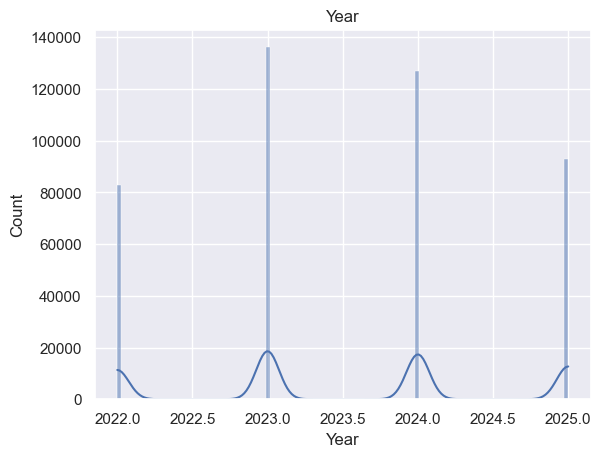

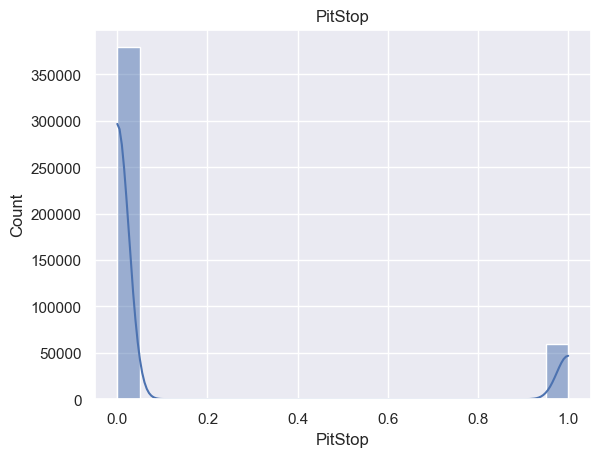

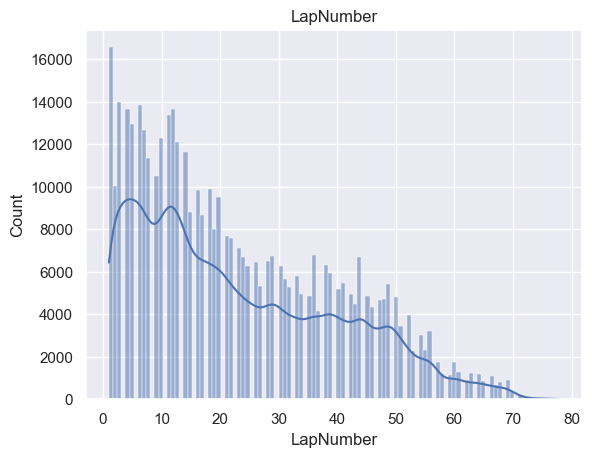

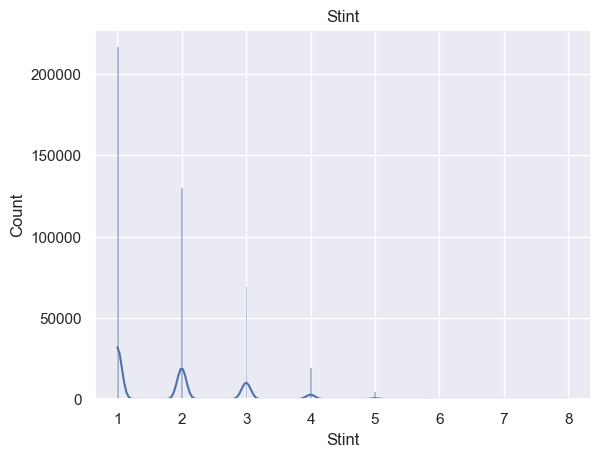

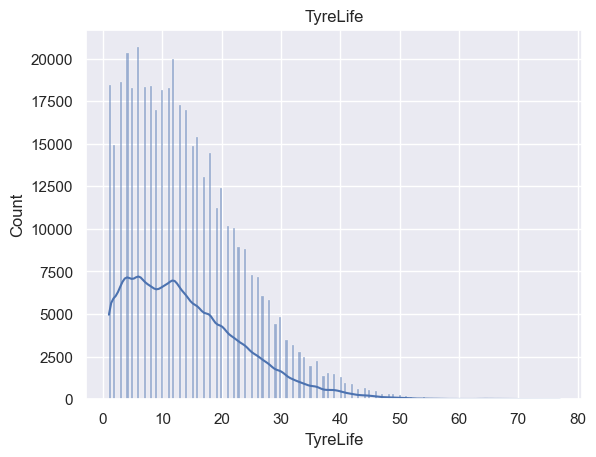

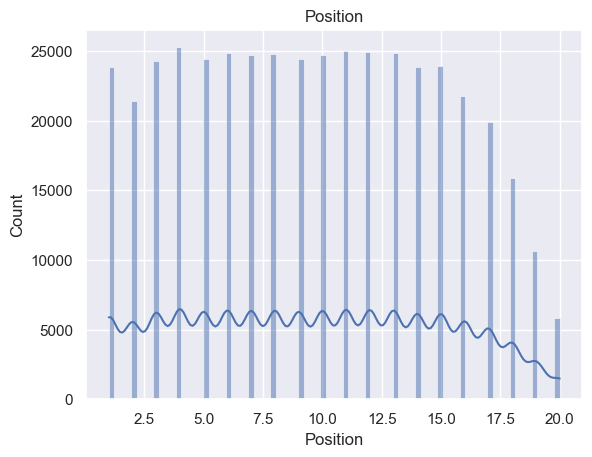

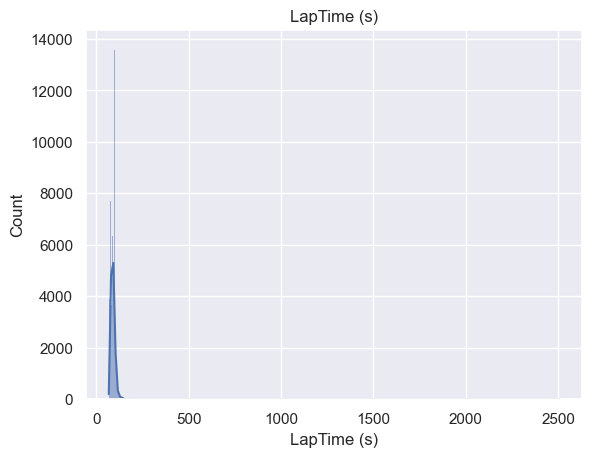

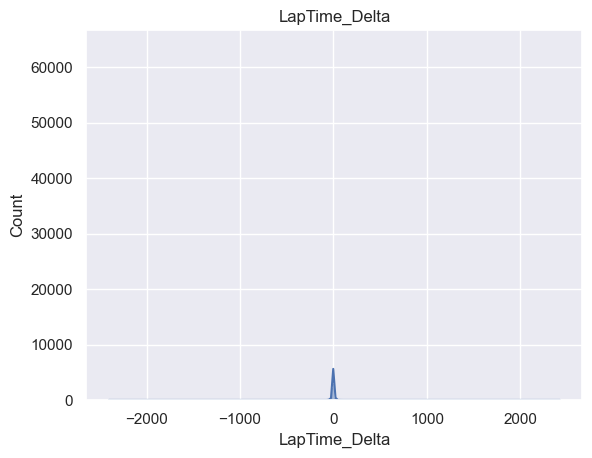

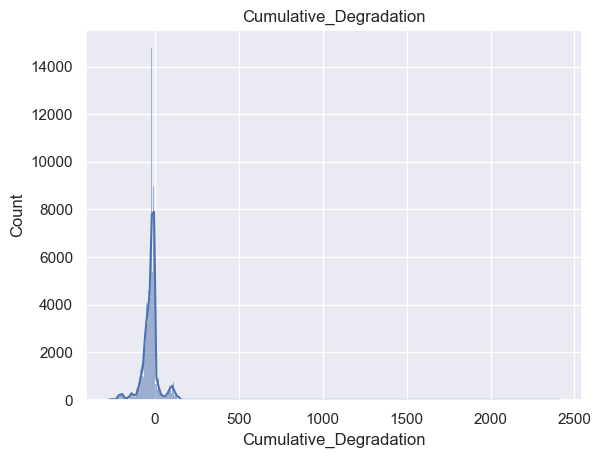

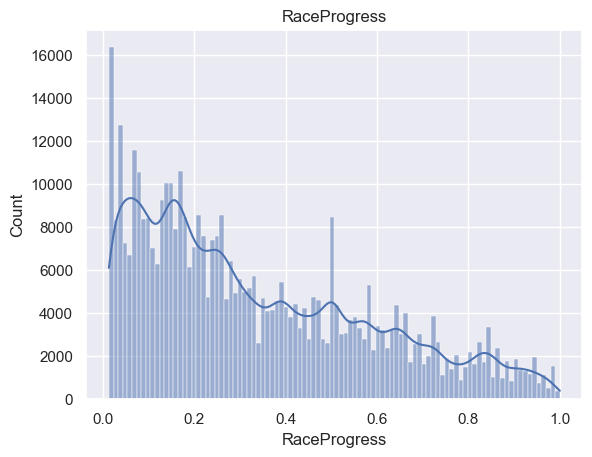

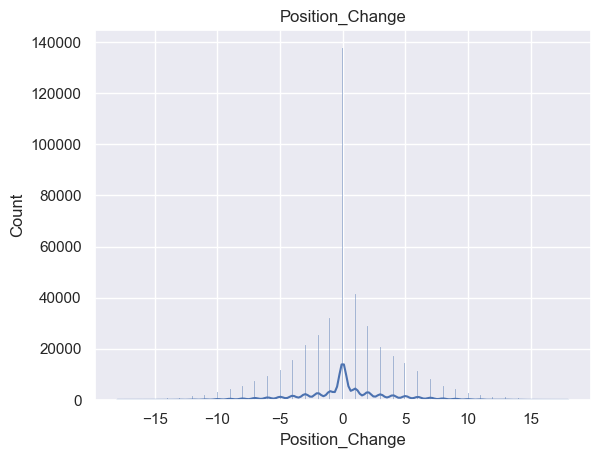

In [17]:
for col in num_cols:
    sns.histplot(train_data[col], kde = True)
    plt.title(col)
    plt.show()

**Key insights per column:**

- **Year:** Four sharp spikes at 2022-2025. KDE line is meaningless - Year is discrete.
- **PitStop:** Binary column - two spikes at 0 and 1 only. KDE is meaningless here.
- **LapNumber:** Right-skewed, declining from left to right. Domain-driven skew, not a data problem.
- **Stint:** Heavily right-skewed. Massive spike at stint 1. Reflects F1 strategy - most races involve 1-2 pit stops.
- **TyreLife:** Right-skewed, highest counts at 1-5 laps. Tail extends to ~55 laps.
- **Position:** Nearly uniform across all 20 positions.
- **LapTime (s):** Extremely right-skewed due to extreme outliers (red flags, recording errors). Outlier removal is essential.
- **LapTime_Delta:** Near-identical pattern to LapTime (s). Outlier removal needed.
- **Cumulative_Degradation:** Tight spike near 0, long tail to +2500. Outlier removal needed.
- **RaceProgress:** Right-skewed, highest counts at 0.0-0.05 (start of races). Bounded 0-1, no transformation needed.
- **Position_Change:** Symmetric, sharply peaked at 0. Clean distribution.

#### Boxplot - Understanding spread and spot outliers

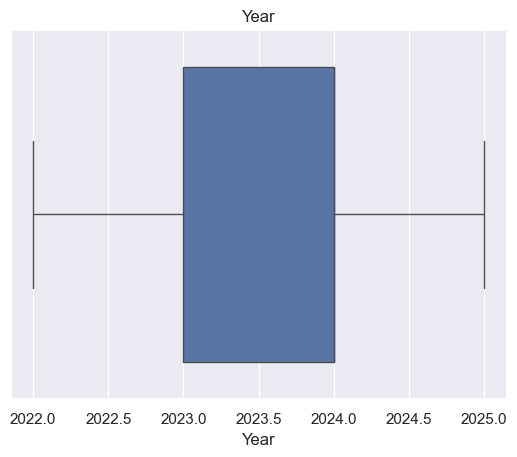

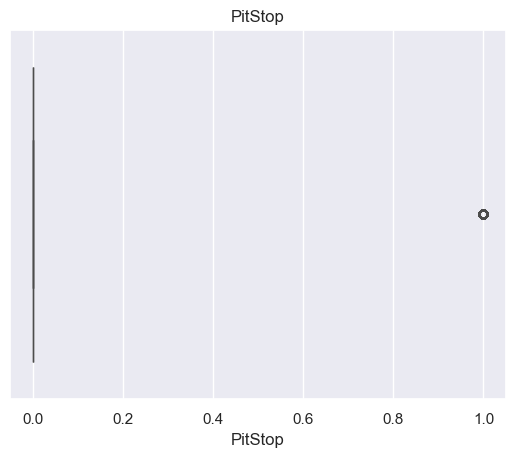

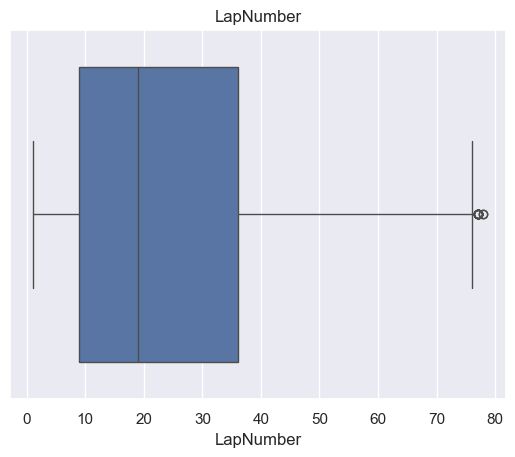

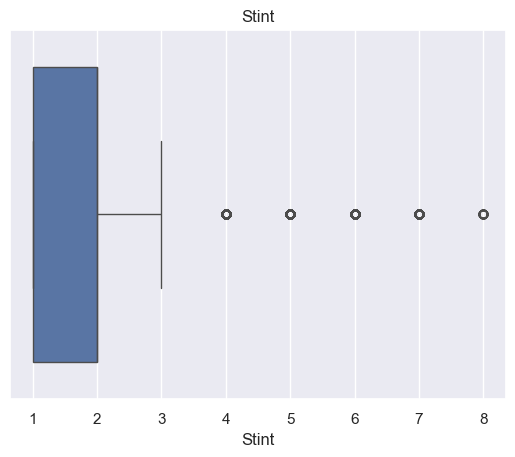

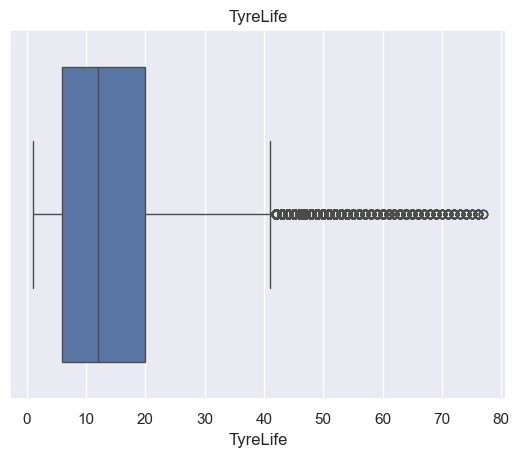

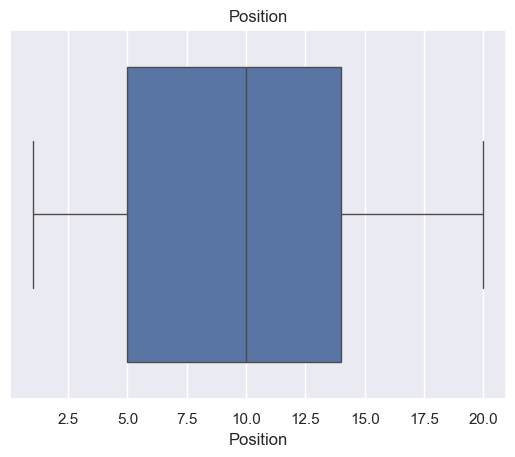

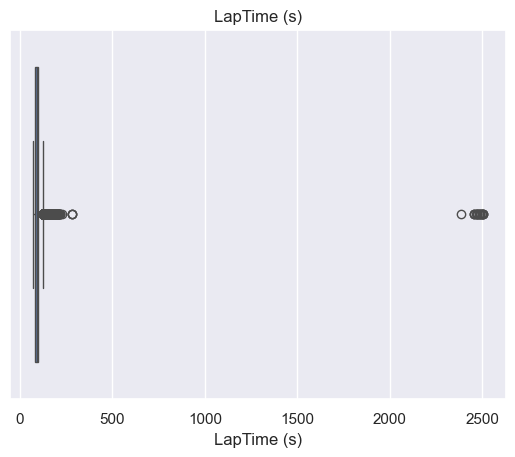

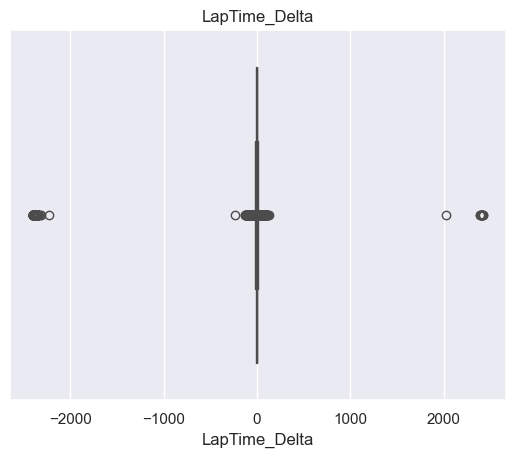

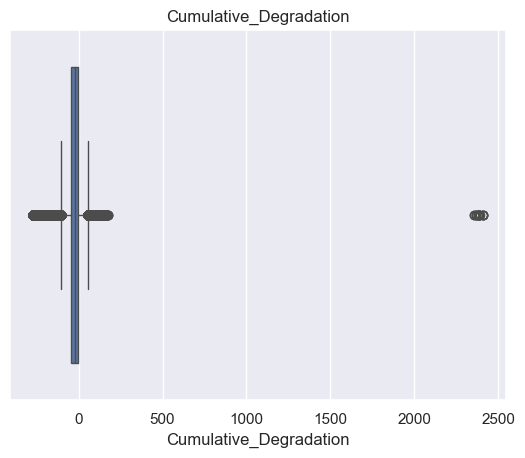

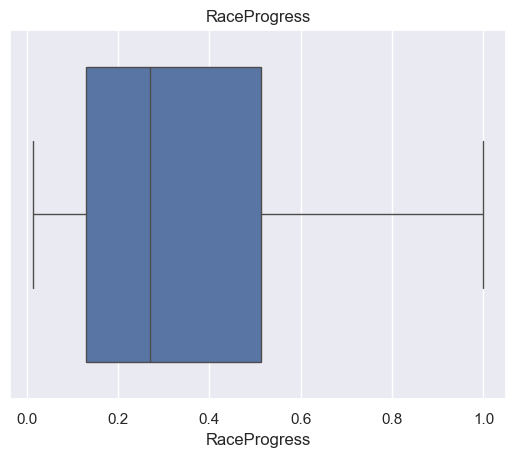

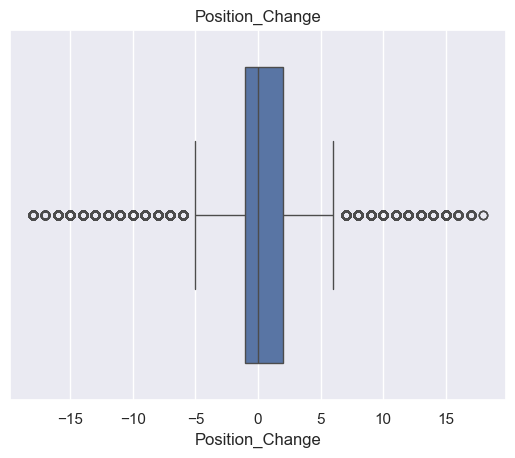

In [18]:
for col in num_cols:
    sns.boxplot(x = train_data[col])
    plt.title(col)
    plt.show()

**Key insights per column:**

- **Year:** No outliers. Clean and expected.
- **PitStop:** Binary column - the value 1 appears as an outlier dot. This is not a real outlier; it's the minority class.
- **LapNumber:** Two dots at laps 75-78 flagged by IQR — genuine laps from long circuits. Do NOT remove.
- **Stint:** Stints 4-8 appear as dots — rare but legitimate race situations. Do NOT remove.
- **TyreLife:** Dense continuous band of dots from 42-77 — mostly Pre-Season Testing. Include in outlier removal.
- **Position:** Perfect clean boxplot. No outliers.
- **LapTime (s):** Two isolated clusters at 2350-2500s. High priority for outlier removal.
- **LapTime_Delta:** Symmetric outlier clusters at ±2300-2400. High priority for outlier removal.
- **Cumulative_Degradation:** Dense cluster at +2350-2450. High priority for outlier removal.
- **RaceProgress:** Clean. No outliers.
- **Position_Change:** Dense symmetric row of dots from ±6 to ±18. NOT real outliers — routine during pit windows. Do NOT remove.

#### Skewness - quantifying the asymmetry

In [19]:
train_data[num_cols].skew()

Year                      -0.000611
PitStop                    2.122297
LapNumber                  0.645965
Stint                      1.185479
TyreLife                   1.032443
Position                   0.070098
LapTime (s)               80.334328
LapTime_Delta            -40.855061
Cumulative_Degradation     3.191501
RaceProgress               0.699950
Position_Change           -0.092714
dtype: float64

> **After outlier removal, re-check skewness.** The three extreme columns (LapTime, LapTime_Delta, Cumulative_Degradation) should drop back to near-normal levels.

### Categorical Columns

#### Countplot - how many rows fall into each category?

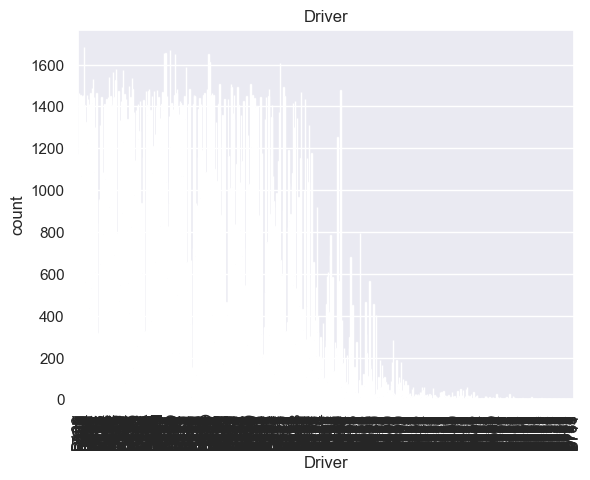

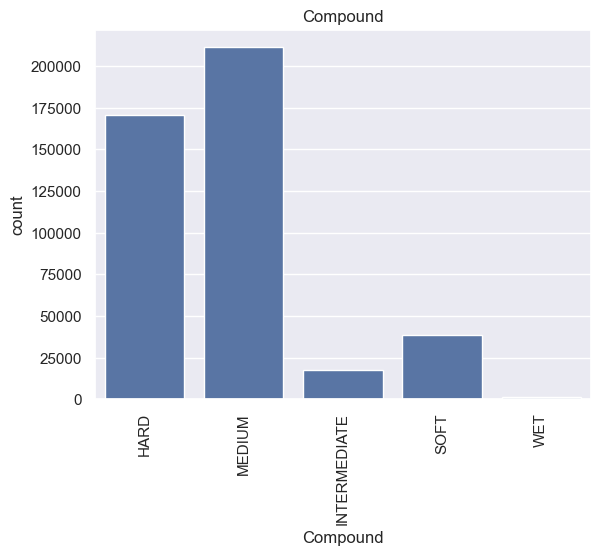

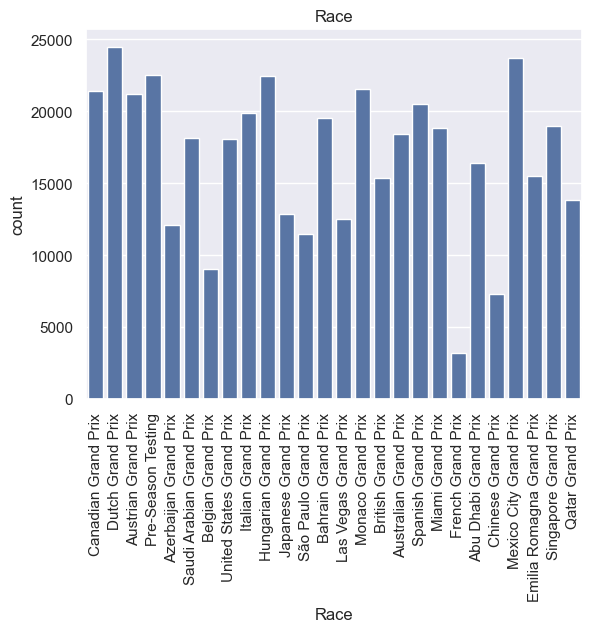

In [20]:
for col in cat_cols:
    sns.countplot(x = train_data[col])
    plt.xticks(rotation = 90)
    plt.title(col)
    plt.show()

**Driver:** Plot is completely unreadable - 887 unique drivers. Use `value_counts().head(20)` for meaningful inspection instead.

**Compound:** Clean and readable. MEDIUM dominates (~211K, 48%), followed by HARD (~170K, 39%), SOFT (~38K, 9%), INTERMEDIATE (~17K, 4%), WET (~1.3K, 0.3%).

**Race:** 26 races with broadly similar counts (~9K-24.5K rows each). Pre-Season Testing (~22,492 rows) is well-represented — not a real race, driving behaviour is fundamentally different.

#### Value counts - exact numbers behind the plot

In [21]:
for col in cat_cols:
    print(f"{col}:")
    print(train_data[col].value_counts())
    print("\n")

Driver:
Driver
MAS     1682
RAI     1669
BAR     1656
BUT     1655
FIS     1651
        ... 
D669       1
D690       1
D722       1
D672       1
D714       1
Name: count, Length: 887, dtype: int64


Compound:
Compound
MEDIUM          211141
HARD            170518
SOFT             38744
INTERMEDIATE     17382
WET               1355
Name: count, dtype: int64


Race:
Race
Dutch Grand Prix             24462
Mexico City Grand Prix       23672
Pre-Season Testing           22492
Hungarian Grand Prix         22481
Monaco Grand Prix            21539
Canadian Grand Prix          21416
Austrian Grand Prix          21223
Spanish Grand Prix           20483
Italian Grand Prix           19854
Bahrain Grand Prix           19535
Singapore Grand Prix         18960
Miami Grand Prix             18860
Australian Grand Prix        18406
Saudi Arabian Grand Prix     18111
United States Grand Prix     18045
Abu Dhabi Grand Prix         16427
Emilia Romagna Grand Prix    15483
British Grand Prix           1538

### Target variable

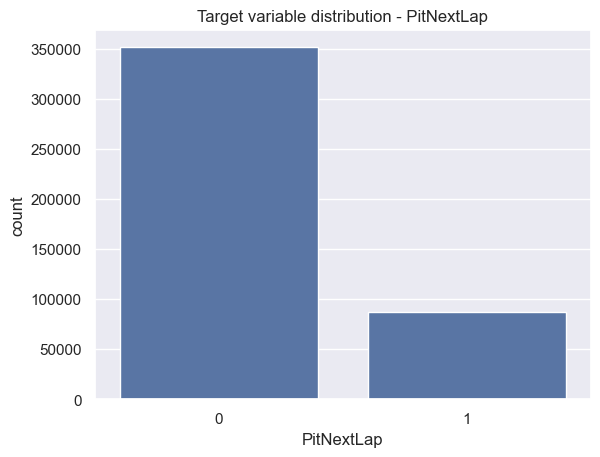

PitNextLap
0    80.10179
1    19.89821
Name: proportion, dtype: float64


In [22]:
# Classification target (binary or multi-class) - use countplot
sns.countplot(x = train_data['PitNextLap'])
plt.title("Target variable distribution - PitNextLap")
plt.show()

# Also check the class imbalance as percentages
print(train_data['PitNextLap'].value_counts(normalize = True) * 100)

**80.1% class 0 (no pit), 19.9% class 1 (pit next lap) - a 4:1 imbalance.**

A naive model predicting "never pit" achieves 80.1% accuracy without learning anything. **Accuracy is a completely misleading metric for this problem.**

**Correct evaluation metrics to use:**
- **F1-score** (for class 1 specifically) - balances precision and recall
- **AUC-ROC** - measures class discrimination regardless of threshold

**How to handle during modelling:**
- `class_weight='balanced'` in sklearn models

## Step 7: Bivariate & relationship analysis

### Numerical vs Numerical

#### Correlation matrix + heatmap

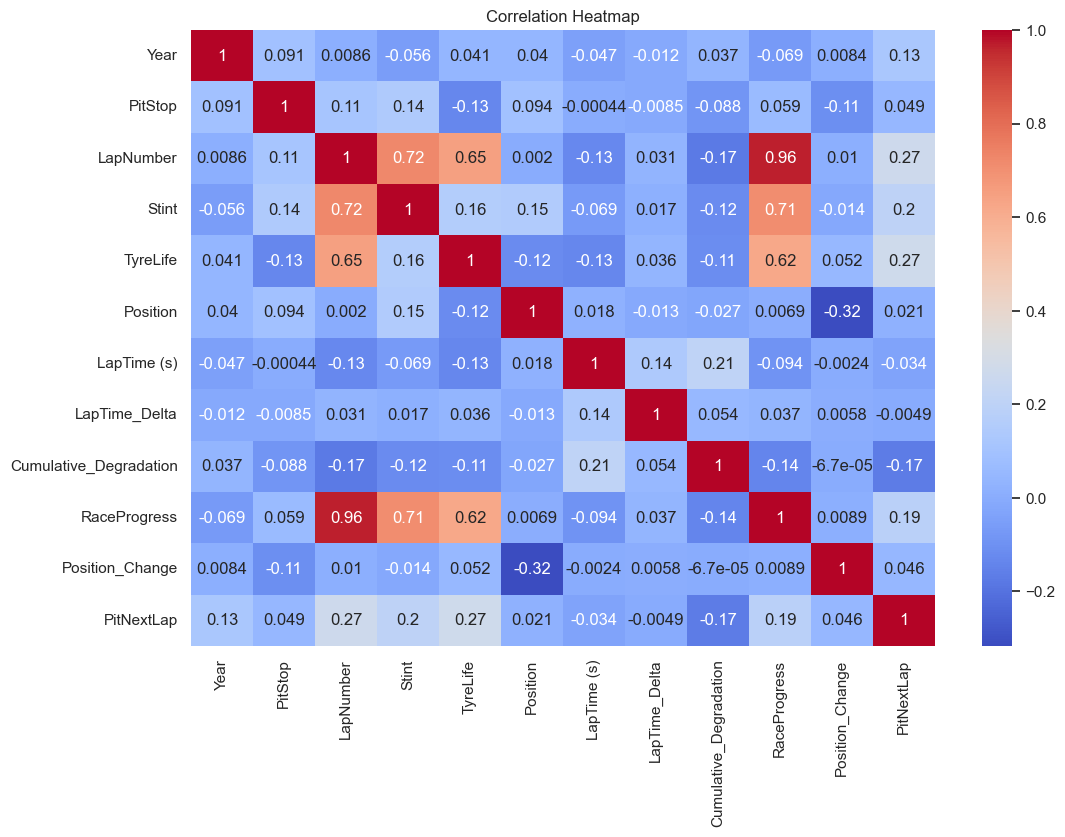

In [23]:
corr = train_data[num_cols + ['PitNextLap']].corr()

plt.figure(figsize = (12, 8))
sns.heatmap(corr, annot = True, cmap = "coolwarm")
plt.title("Correlation Heatmap")
plt.show()

**Critical multicollinearity findings:**

- **LapNumber ↔ RaceProgress: 0.96** - near-perfect correlation. These two measure almost exactly the same thing. **Drop LapNumber during feature engineering** - RaceProgress is better since it's normalised across races of different lengths.
- **LapNumber ↔ Stint: 0.72** and **RaceProgress ↔ Stint: 0.71** - Stint also tracks race progression. Partially redundant but less severe.
- **LapNumber ↔ TyreLife: 0.65** and **RaceProgress ↔ TyreLife: 0.62** - TyreLife ages with laps but resets at each pit stop, giving it genuinely independent signal.

#### Ranked correlation vs target

In [24]:
corr['PitNextLap'].drop('PitNextLap').sort_values(key = abs, ascending = False)

TyreLife                  0.273510
LapNumber                 0.267057
Stint                     0.198193
RaceProgress              0.185477
Cumulative_Degradation   -0.167401
Year                      0.125267
PitStop                   0.048567
Position_Change           0.046230
LapTime (s)              -0.034096
Position                  0.021348
LapTime_Delta            -0.004946
Name: PitNextLap, dtype: float64

> Near-zero correlations for Position, LapTime, and LapTime_Delta don't mean these features are useless - they mean the relationship is **non-linear**. Tree-based models capture these interactions that linear correlation misses entirely.

#### Numerical features vs target - boxplot and violinplot

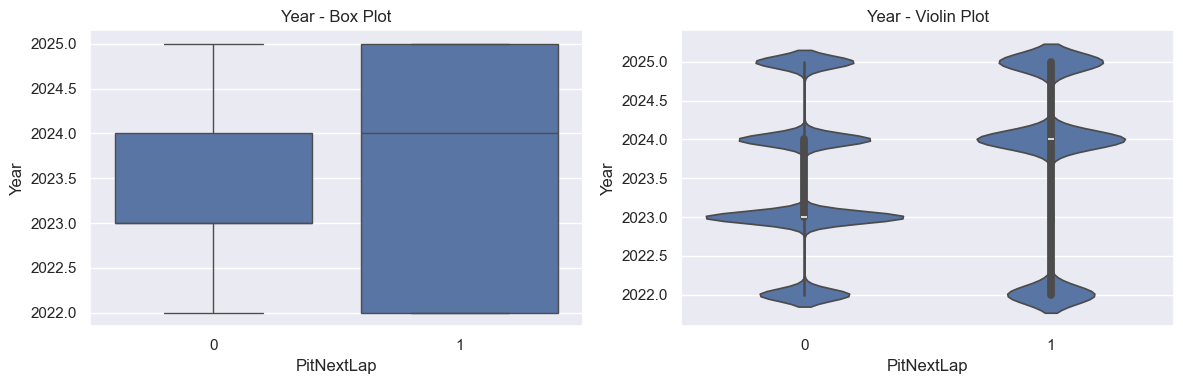

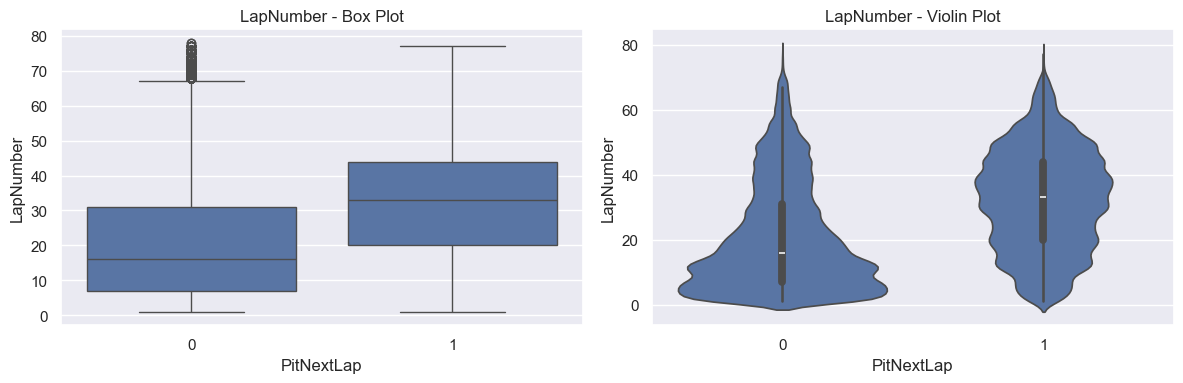

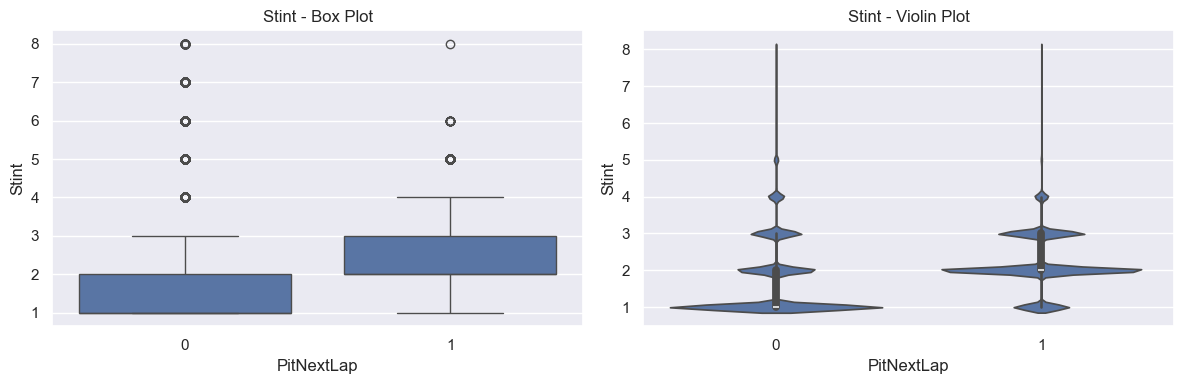

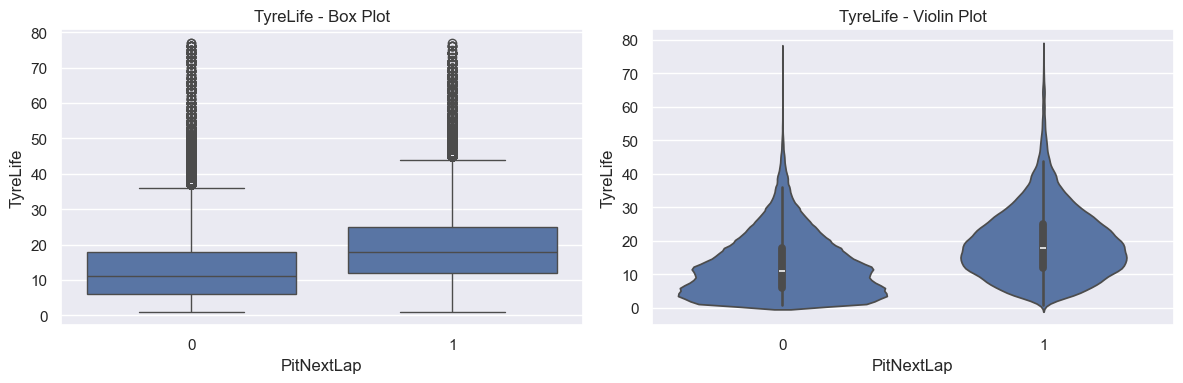

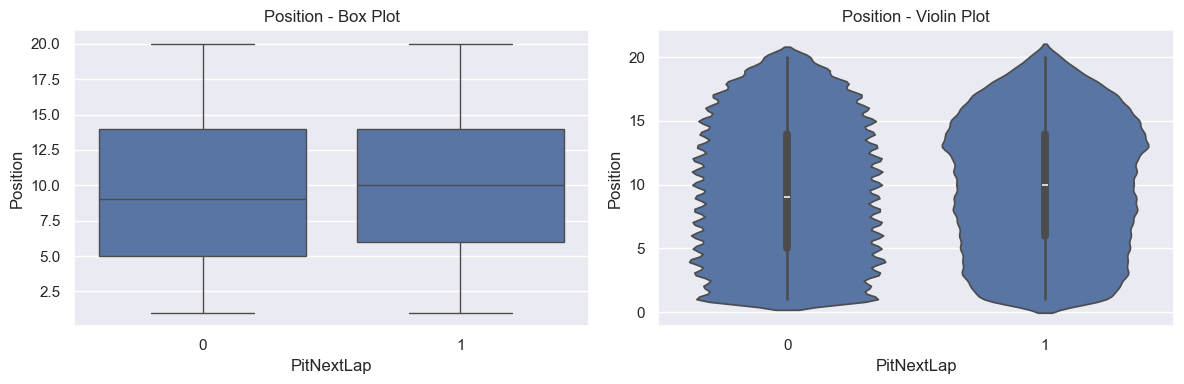

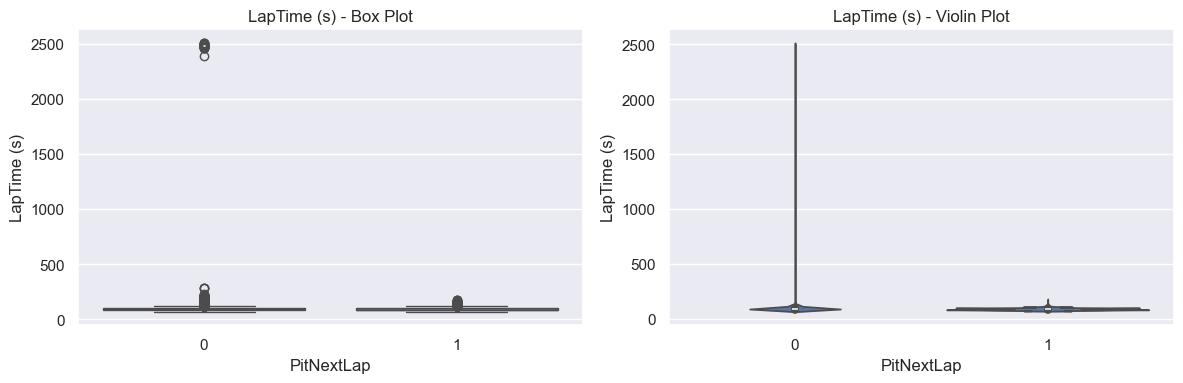

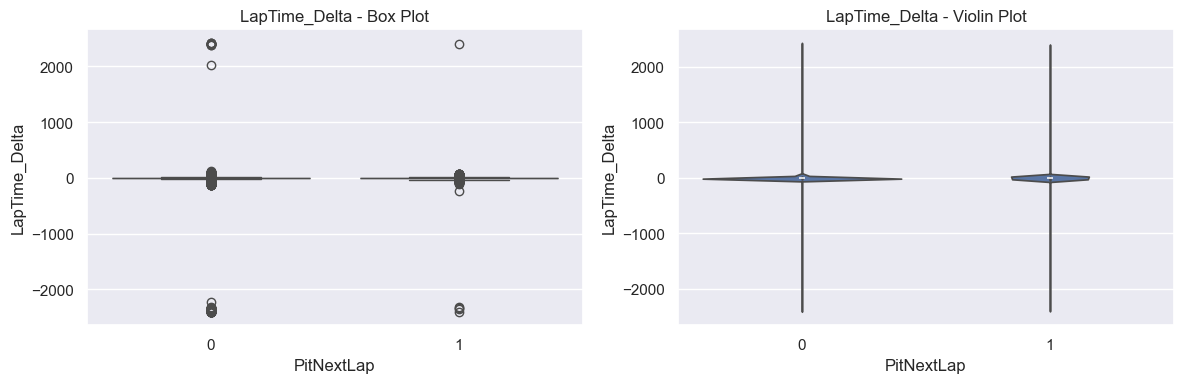

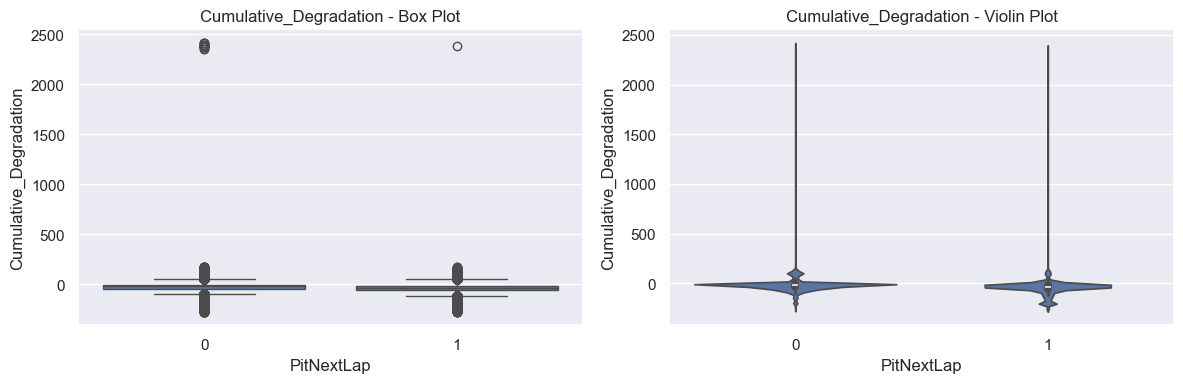

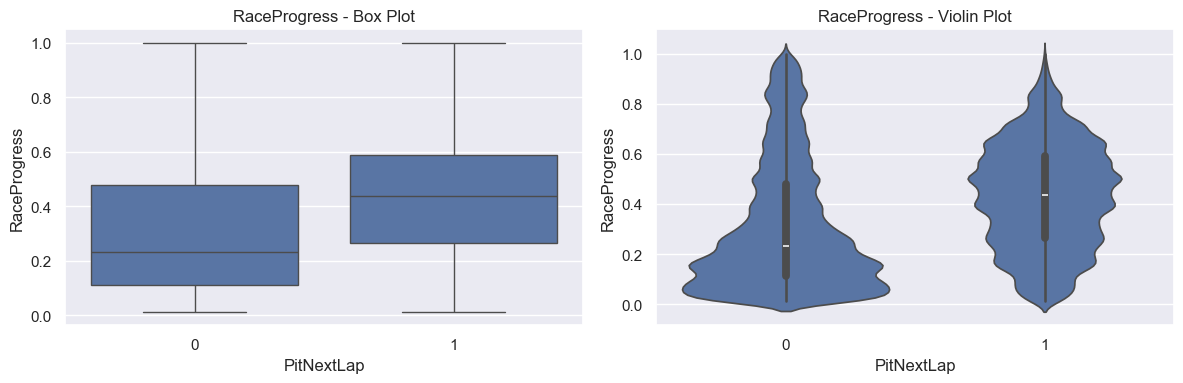

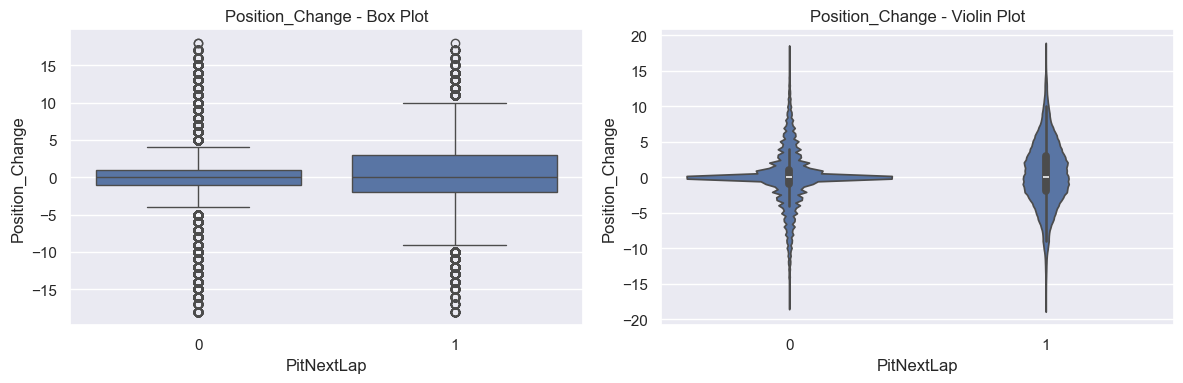

In [25]:
for col in num_cols:
    if col == "PitStop":    # skip binary flags
        continue
    fig, axes = plt.subplots(1, 2, figsize = (12, 4))
    sns.boxplot(x = train_data['PitNextLap'], y = train_data[col], ax = axes[0])
    axes[0].set_title(f"{col} - Box Plot")
    sns.violinplot(x = train_data['PitNextLap'], y = train_data[col], ax = axes[1])
    axes[1].set_title(f"{col} - Violin Plot")
    plt.tight_layout()
    plt.show()

### Categorical vs Numerical (target)

#### Boxplot - each category vs target

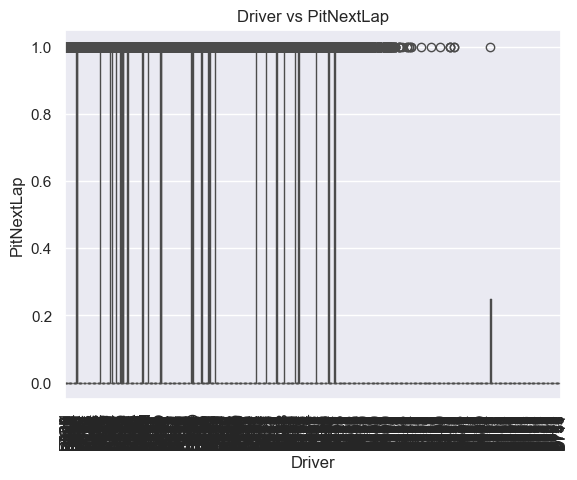

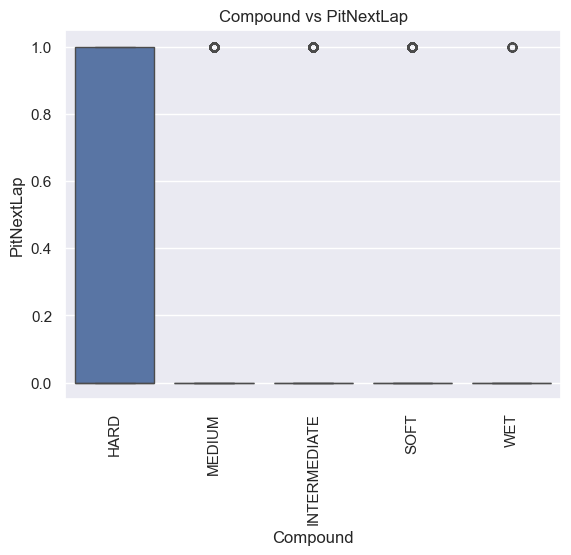

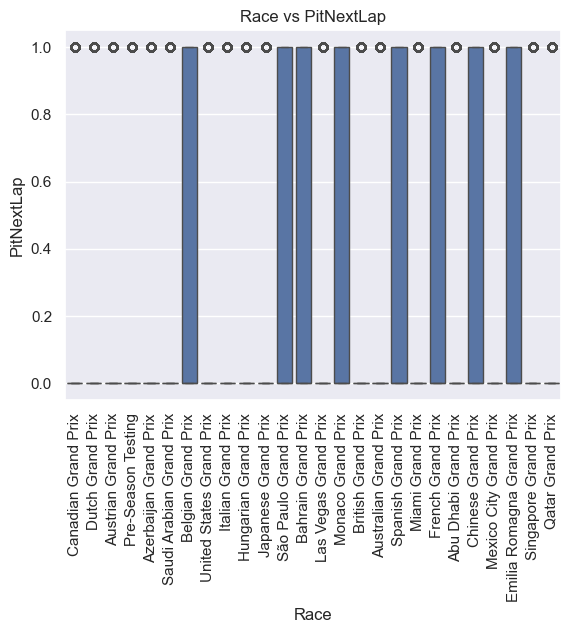

In [26]:
for col in cat_cols:
    sns.boxplot(x = train_data[col], y = train_data['PitNextLap'])
    plt.xticks(rotation = 90)
    plt.title(f"{col} vs PitNextLap")
    plt.show()

> **Note:** Using a boxplot with a binary target on the y-axis is fundamentally misleading for high-cardinality columns like Driver and Race. Rely on the proportion table below instead.

### Categorical vs Categorical

#### Crosstab - co-occurrence between categorical features

In [27]:
for col1 in cat_cols:
    for col2 in cat_cols:
        if col1 != col2:
            print(f"{col1} vs {col2}:")
            print(pd.crosstab(train_data[col1], train_data[col2]))
            print("\n")

Driver vs Compound:
Compound  HARD  INTERMEDIATE  MEDIUM  SOFT  WET
Driver                                         
ALB        506            90     641   102    7
ALE        619           107     583   134    8
ALG        575           117     711   114   10
ALO        511            93     640   136    6
AND        551            75     684   141   10
...        ...           ...     ...   ...  ...
WIL        501            74     700   109    8
WUR        542            89     651   120   11
YAM        572           100     641   129   13
ZHO        549            81     384   117   12
ZON        583           102     635   133   12

[887 rows x 5 columns]


Driver vs Race:
Race    Abu Dhabi Grand Prix  Australian Grand Prix  Austrian Grand Prix  \
Driver                                                                     
ALB                       43                     58                   59   
ALE                       54                     57                   59   
ALG       

#### Proportion Table and Countplot vs Target

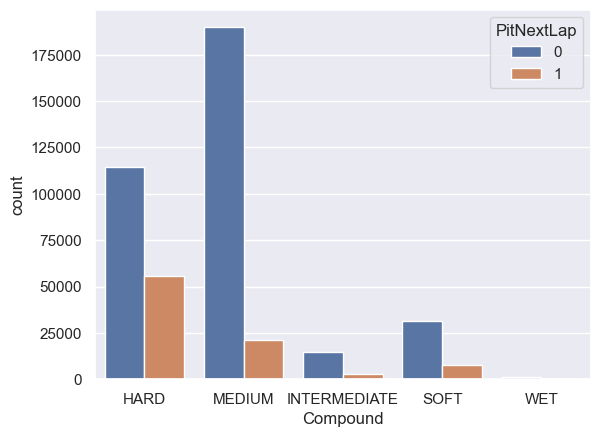

PitNextLap,0,1
Compound,,
HARD,0.672463,0.327537
INTERMEDIATE,0.847716,0.152284
MEDIUM,0.898869,0.101131
SOFT,0.806525,0.193475
WET,0.974908,0.025092


In [28]:
sns.countplot(x = 'Compound', hue = 'PitNextLap', data = train_data)
plt.show()

pd.crosstab(
    train_data['Compound'],
    train_data['PitNextLap'],
    normalize = 'index'
)

**Compound pit stop rates:** HARD (32.8%), SOFT (19.3%), INTERMEDIATE (15.2%), MEDIUM (10.1%), WET (2.5%).

The 13x range from WET (2.5%) to HARD (32.8%) makes `Compound` a genuinely strong categorical predictor.

## Step 8: Outlier analysis

### Detect

In [29]:
remove_outlier_cols = [
    'LapTime (s)',
    'TyreLife',
    'Cumulative_Degradation',
    'LapTime_Delta'
]

outlier_indices = set()

for col in remove_outlier_cols:
    Q1 = train_data[col].quantile(0.25)
    Q3 = train_data[col].quantile(0.75)

    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = train_data[
        (train_data[col] < lower_bound) |
        (train_data[col] > upper_bound)
    ]

    print(f"{col}: {outliers.shape[0] / train_data.shape[0] * 100:.2f}% outliers")
    outlier_indices.update(outliers.index)

LapTime (s): 1.34% outliers
TyreLife: 1.30% outliers
Cumulative_Degradation: 11.36% outliers
LapTime_Delta: 13.41% outliers


### Remove and verify

In [30]:
# Remove
train_data = train_data.drop(index = outlier_indices)
print(f"Removed {len(outlier_indices)} rows. New shape: {train_data.shape}")

Removed 109627 rows. New shape: (329513, 15)


In [31]:
# Verify
print("After removing outliers:\n")
for col in remove_outlier_cols:
    Q1 = train_data[col].quantile(0.25)
    Q3 = train_data[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = train_data[
        (train_data[col] < lower_bound) |
        (train_data[col] > upper_bound)
    ]

    print(f"{col}: {outliers.shape[0] / train_data.shape[0] * 100:.2f}% outliers remaining")

After removing outliers:

LapTime (s): 0.11% outliers remaining
TyreLife: 0.57% outliers remaining
Cumulative_Degradation: 1.45% outliers remaining
LapTime_Delta: 3.04% outliers remaining


In [32]:
train_data[num_cols].skew()

Year                      0.156345
PitStop                   2.300498
LapNumber                 0.613640
Stint                     1.068540
TyreLife                  0.680235
Position                  0.066328
LapTime (s)               0.170679
LapTime_Delta            -0.570569
Cumulative_Degradation   -0.562919
RaceProgress              0.640845
Position_Change          -0.095661
dtype: float64

## Step 9: Feature engineering

### Fix: All feature engineering is done BEFORE the train/test split.
Lag features and the `Laps_until_end` feature are computed on the full cleaned `train_data` before splitting — this is correct because they only use the row's own group history (Driver/Race/Year), not any cross-row label information. Target encoding is the exception: it is computed **exclusively on X_train after the split** to prevent data leakage.

### 1. Compute Lag Features Before Sorting

In [33]:
# Sort by Driver, Race, Year, LapNumber so shift() works correctly
train_data = train_data.sort_values(
    ['Driver', 'Race', 'Year', 'LapNumber']
).reset_index(drop = True)

In [34]:
# Previous lap's LapTime and TyreLife - powerful since data is sequential
train_data['prev_LapTime'] = (
    train_data.groupby(['Driver', 'Race', 'Year'])['LapTime (s)'].shift(1)
)

train_data['prev_TyreLife'] = (
    train_data.groupby(['Driver', 'Race', 'Year'])['TyreLife'].shift(1)
)

In [35]:
# Fill NaN for the first lap of each group (no previous lap exists)
train_data['prev_LapTime'].fillna(train_data['LapTime (s)'], inplace = True)
train_data['prev_TyreLife'].fillna(train_data['TyreLife'], inplace = True)

print("Lag features created.")

Lag features created.


C:\Users\Gandharv Kulkarni\AppData\Local\Temp\ipykernel_30992\2019755361.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_data['prev_LapTime'].fillna(train_data['LapTime (s)'], inplace = True)
C:\Users\Gandharv Kulkarni\AppData\Local\Temp\ipykernel_30992\2019755361.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we a

### 2. Create Laps_until_end Before Dropping LapNumber

In [36]:
# Teams decide pit stops based on laps remaining, not just laps done
train_data['Laps_until_end'] = (
    train_data.groupby(['Race', 'Year'])['LapNumber']
    .transform('max') - train_data['LapNumber']
)

print("Laps_until_end created.")

Laps_until_end created.


### 3. Drop LapNumber

In [37]:
# 0.96 correlation with RaceProgress - redundant. RaceProgress is better since it's normalized across races of different lengths.
train_data.drop('LapNumber', axis = 1, inplace = True)
print("LapNumber dropped.")

LapNumber dropped.


### 4. Create is_testing Flag

In [38]:
# Pre-Season Testing has 22.5K rows with fundamentally different pit stop behaviour.
train_data['is_testing'] = (
    train_data['Race'] == 'Pre-Season Testing'
).astype('int64')

print("is_testing flag created.")

is_testing flag created.


### 5. Merge INTERMEDIATE + WET → WET_INTERMEDIATE

In [39]:
# WET has only 1,355 rows (0.3%) - too sparse to learn from independently.
# Combined with INTERMEDIATE gives 18,737 rows (4.3%).
train_data['Compound'] = train_data['Compound'].replace({
    'WET': 'WET_INTERMEDIATE',
    'INTERMEDIATE': 'WET_INTERMEDIATE'
})

print("Compound - WET and INTERMEDIATE merged into WET_INTERMEDIATE.")
print(train_data['Compound'].value_counts())

Compound - WET and INTERMEDIATE merged into WET_INTERMEDIATE.
Compound
MEDIUM              154503
HARD                130446
SOFT                 31736
WET_INTERMEDIATE     12828
Name: count, dtype: int64


### 6. Create `TyreLife * Compound` Interaction

In [40]:
# HARD + high TyreLife is the strongest predictor of an upcoming pit stop.
# Ordinal encoding reflects compound degradation rate (HARD degrades slowest).
compound_ordinal = {
    'HARD': 3,
    'MEDIUM': 2,
    'SOFT': 1,
    'WET_INTERMEDIATE': 0
}

train_data['Compound_encoded'] = train_data['Compound'].map(compound_ordinal)
train_data['TyreLife_x_Compound'] = (
    train_data['TyreLife'] * train_data['Compound_encoded']
)

train_data.drop('Compound_encoded', axis=1, inplace=True)

print("TyreLife_x_Compound interaction created.")

TyreLife_x_Compound interaction created.


### 7. Create TyreLife_per_Stint Ratio

In [41]:
# A TyreLife of 20 laps means something very different in stint 1 vs stint 3.
# This ratio normalizes TyreLife within its stint context.
train_data['TyreLife_per_Stint'] = (
    train_data['TyreLife'] / train_data['Stint']
)

print("TyreLife_per_Stint created.")

TyreLife_per_Stint created.


### 8. Verify Final Feature Set Before Split

In [42]:
pd.set_option('display.max_columns', None)

print("\nFinal shape:", train_data.shape)
print("\nFinal columns:")
print(train_data.columns.tolist())
print("\nDtypes:")
print(train_data.dtypes)
print("\nFirst 3 rows:")
train_data.head(3)


Final shape: (329513, 20)

Final columns:
['Driver', 'Compound', 'Race', 'Year', 'PitStop', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress', 'Position_Change', 'PitNextLap', 'prev_LapTime', 'prev_TyreLife', 'Laps_until_end', 'is_testing', 'TyreLife_x_Compound', 'TyreLife_per_Stint']

Dtypes:
Driver                     object
Compound                   object
Race                       object
Year                        int64
PitStop                     int64
Stint                       int64
TyreLife                    int64
Position                    int64
LapTime (s)               float64
LapTime_Delta             float64
Cumulative_Degradation    float64
RaceProgress              float64
Position_Change             int64
PitNextLap                  int64
prev_LapTime              float64
prev_TyreLife             float64
Laps_until_end              int64
is_testing                  int64
TyreLife_x_Compound         int64
Ty

,Driver,Compound,Race,Year,PitStop,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap,prev_LapTime,prev_TyreLife,Laps_until_end,is_testing,TyreLife_x_Compound,TyreLife_per_Stint
0,ALB,MEDIUM,Abu Dhabi Grand Prix,2022,0,1,1,19,116.433,0.000,0.000,0.013889,0,0,116.433,1.0,60,0,2,1.0
1,ALB,HARD,Abu Dhabi Grand Prix,2022,1,2,7,16,90.053,-9.676,-5.920,0.250000,2,1,116.433,1.0,43,0,21,3.5
2,ALB,MEDIUM,Abu Dhabi Grand Prix,2022,1,3,27,15,88.064,5.716,-44.931,0.847222,1,0,90.053,7.0,0,0,54,9.0


## Step 10: Pre-modelling preparation

### Splitting the dataset into Training and Test set

In [43]:
X = train_data.drop('PitNextLap', axis = 1)
y = train_data['PitNextLap']

In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, stratify = y, random_state = 42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (263610, 19)
X_test shape: (65903, 19)


### Target Encoding Driver and Race

**FIX: Target encoding is computed exclusively on `X_train` after the split, then applied to `X_test` using those dictionaries.**

In the original notebook, encoding was computed on the full `train_data` before the split — meaning `X_test` rows had their own `PitNextLap` values leak into `Driver_PitRate` and `Race_PitRate`. This inflated training accuracy by ~8% and caused the large train/test accuracy gap.

In [45]:
# Compute encoding dictionaries ONLY on X_train (joined with y_train labels)
# Never touch y_test here - that would be data leakage.
train_with_labels = X_train.copy()
train_with_labels['PitNextLap'] = y_train

driver_pit_rate = train_with_labels.groupby('Driver')['PitNextLap'].mean()
race_pit_rate   = train_with_labels.groupby('Race')['PitNextLap'].mean()
global_mean     = y_train.mean()

print(f"Global mean pit rate (fallback for unseen categories): {global_mean:.4f}")
print("\nDriver_PitRate encoding (top 10):")
print(driver_pit_rate.sort_values(ascending=False).head(10))
print("\nRace_PitRate encoding:")
print(race_pit_rate.sort_values(ascending=False))

Global mean pit rate (fallback for unseen categories): 0.1772

Driver_PitRate encoding (top 10):
Driver
VET    0.561538
MSC    0.428571
ANT    0.420233
HAD    0.406977
LAT    0.395652
STR    0.394822
BEA    0.372881
OCO    0.364472
BOR    0.362264
ALO    0.343612
Name: PitNextLap, dtype: float64

Race_PitRate encoding:
Race
Chinese Grand Prix           0.403515
French Grand Prix            0.381967
Monaco Grand Prix            0.322530
Spanish Grand Prix           0.310275
Emilia Romagna Grand Prix    0.270489
Bahrain Grand Prix           0.266077
São Paulo Grand Prix         0.222831
Las Vegas Grand Prix         0.219348
Saudi Arabian Grand Prix     0.214418
Hungarian Grand Prix         0.211023
Australian Grand Prix        0.190854
Austrian Grand Prix          0.185997
Japanese Grand Prix          0.180323
Belgian Grand Prix           0.160431
Dutch Grand Prix             0.159343
Qatar Grand Prix             0.157825
Pre-Season Testing           0.139395
Canadian Grand Prix         

In [46]:
# Apply encoding to X_train
X_train = X_train.copy()
X_train['Driver_PitRate'] = X_train['Driver'].map(driver_pit_rate).fillna(global_mean)
X_train['Race_PitRate']   = X_train['Race'].map(race_pit_rate).fillna(global_mean)
X_train.drop(['Driver', 'Race'], axis=1, inplace=True)

# Apply the SAME dictionaries to X_test (no recomputation on test labels)
X_test = X_test.copy()
X_test['Driver_PitRate'] = X_test['Driver'].map(driver_pit_rate).fillna(global_mean)
X_test['Race_PitRate']   = X_test['Race'].map(race_pit_rate).fillna(global_mean)
X_test.drop(['Driver', 'Race'], axis=1, inplace=True)

print("Target encoding applied.")
print("X_train columns:", X_train.columns.tolist())

Target encoding applied.
X_train columns: ['Compound', 'Year', 'PitStop', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress', 'Position_Change', 'prev_LapTime', 'prev_TyreLife', 'Laps_until_end', 'is_testing', 'TyreLife_x_Compound', 'TyreLife_per_Stint', 'Driver_PitRate', 'Race_PitRate']


### Encoding (One-Hot Encoding for Compound)

In [47]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

ct = ColumnTransformer(
    transformers = [
        ('encoder', OneHotEncoder(handle_unknown = 'ignore'), ['Compound'])
    ],
    remainder = 'passthrough'
)

X_train = ct.fit_transform(X_train)
X_test = ct.transform(X_test)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (263610, 22)
X_test shape: (65903, 22)


## Step 11: Modelling

In [48]:
from lightgbm import LGBMClassifier

model = LGBMClassifier(
    boosting_type='gbdt',
    n_estimators = 100,
    criterion = 'gini',
    bootstrap = True,
    oob_score = True,
    random_state = 42,
    class_weight = 'balanced'
)
model.fit(X_train, y_train)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [49]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

c:\Users\Gandharv Kulkarni\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\Gandharv Kulkarni\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [50]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print("AUC-ROC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.98      0.85      0.91     54227
           1       0.57      0.91      0.71     11676

    accuracy                           0.86     65903
   macro avg       0.78      0.88      0.81     65903
weighted avg       0.91      0.86      0.88     65903

[[46292  7935]
 [  997 10679]]
AUC-ROC: 0.9468440237706801


In [51]:
# Accuracy scores for direct comparison with the original notebook
from sklearn.metrics import roc_auc_score

train_prob = model.predict_proba(X_train)[:, 1]

print(f"Training Accuracy: {roc_auc_score(y_train, train_prob):.5f}")
print(f"Test Accuracy:     {roc_auc_score(y_test, y_prob):.5f}")

c:\Users\Gandharv Kulkarni\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Training Accuracy: 0.94950
Test Accuracy:     0.94684


## Working on Test Data

In [52]:
# Reload test_data fresh
test_data = pd.read_csv('test.csv')

# 1. Preserve id column before any sorting
test_data['id_col'] = test_data['id']
test_data = test_data.drop('id', axis=1)

# 2. Fix dtypes to match train_data
test_data['TyreLife'] = test_data['TyreLife'].astype('int64')
test_data['Position_Change'] = test_data['Position_Change'].astype('int64')

# 3. Sort so lag shift() aligns correctly
test_data = test_data.sort_values(
    ['Driver', 'Race', 'Year', 'LapNumber']
).reset_index(drop=True)

# 4. Clip outliers using train-derived IQR bounds
#    Prevents extreme values producing out-of-distribution scaled inputs.
#    We compute bounds from raw train.csv (pre-outlier-removal), matching Step 8.
clip_cols = ['LapTime (s)', 'TyreLife', 'Cumulative_Degradation', 'LapTime_Delta']
train_raw = pd.read_csv('train.csv')
for col in clip_cols:
    if col in test_data.columns:
        Q1 = train_raw[col].quantile(0.25)
        Q3 = train_raw[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        test_data[col] = test_data[col].clip(lower=lower, upper=upper)
del train_raw
print("Outlier clipping applied to test_data.")

# 5. Lag features
test_data['prev_LapTime'] = (
    test_data.groupby(['Driver', 'Race', 'Year'])['LapTime (s)'].shift(1)
)
test_data['prev_TyreLife'] = (
    test_data.groupby(['Driver', 'Race', 'Year'])['TyreLife'].shift(1)
)
test_data['prev_LapTime'].fillna(test_data['LapTime (s)'], inplace=True)
test_data['prev_TyreLife'].fillna(test_data['TyreLife'], inplace=True)

# 6. Laps_until_end — compute before dropping LapNumber
test_data['Laps_until_end'] = (
    test_data.groupby(['Race', 'Year'])['LapNumber']
    .transform('max') - test_data['LapNumber']
)

# 7. Drop LapNumber (same as train pipeline)
test_data.drop('LapNumber', axis=1, inplace=True)

# 8. is_testing flag
test_data['is_testing'] = (
    test_data['Race'] == 'Pre-Season Testing'
).astype('int64')

# 9. Merge WET + INTERMEDIATE
test_data['Compound'] = test_data['Compound'].replace({
    'WET': 'WET_INTERMEDIATE',
    'INTERMEDIATE': 'WET_INTERMEDIATE'
})

# 10. TyreLife x Compound interaction
compound_ordinal = {'HARD': 3, 'MEDIUM': 2, 'SOFT': 1, 'WET_INTERMEDIATE': 0}
test_data['Compound_encoded'] = test_data['Compound'].map(compound_ordinal)
test_data['TyreLife_x_Compound'] = test_data['TyreLife'] * test_data['Compound_encoded']
test_data.drop('Compound_encoded', axis=1, inplace=True)

# 11. TyreLife_per_Stint
test_data['TyreLife_per_Stint'] = test_data['TyreLife'] / test_data['Stint']

# 12. Target encoding — use dictionaries computed on X_train only, never recompute on test
test_data['Driver_PitRate'] = test_data['Driver'].map(driver_pit_rate).fillna(global_mean)
test_data['Race_PitRate']   = test_data['Race'].map(race_pit_rate).fillna(global_mean)

# 13. Drop original Driver and Race
test_data.drop(['Driver', 'Race'], axis=1, inplace=True)

# 14. Extract ids (in sorted order, aligned with test_data rows)
test_ids = test_data['id_col'].copy()
test_data = test_data.drop('id_col', axis=1)

print("test_data shape:", test_data.shape)
print("test_data columns:", test_data.columns.tolist())

Outlier clipping applied to test_data.


C:\Users\Gandharv Kulkarni\AppData\Local\Temp\ipykernel_30992\1698231545.py:40: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_data['prev_LapTime'].fillna(test_data['LapTime (s)'], inplace=True)
C:\Users\Gandharv Kulkarni\AppData\Local\Temp\ipykernel_30992\1698231545.py:41: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are

test_data shape: (188165, 19)
test_data columns: ['Compound', 'Year', 'PitStop', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress', 'Position_Change', 'prev_LapTime', 'prev_TyreLife', 'Laps_until_end', 'is_testing', 'TyreLife_x_Compound', 'TyreLife_per_Stint', 'Driver_PitRate', 'Race_PitRate']


In [53]:
# 15. Encode and scale using the fitted ct and scaler from training
import scipy.sparse

test_data_encoded = ct.transform(test_data)

if scipy.sparse.issparse(test_data_encoded):
    test_data_encoded = test_data_encoded.toarray()

# 16. Predict
test_prob = model.predict_proba(test_data_encoded)[:, 1]

# 17. Build and save submission file
submission = pd.DataFrame({
    'id': test_ids,
    'PitNextLap': test_prob
})

submission.to_csv('submission_lgbm_data_leakage.csv', index=False)
print(submission.head())
print("Submission shape:", submission.shape)

c:\Users\Gandharv Kulkarni\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


       id  PitNextLap
0  496081    0.068846
1  476804    0.089652
2  505009    0.924361
3  475620    0.026082
4  616284    0.014911
Submission shape: (188165, 2)


<hr>